# LAB 5 — Notebook 03: Clustering Paradigm
## QoE Prediction from QoS Data | EEF606 | University of Buea

---
**Prerequisite:** Run `lab5_00_data_generator.ipynb` first.

## Why Clustering is the THIRD way to frame this problem

Classification needs LABELS — we had to tell the model what 'Poor' and 'Excellent' mean.
But what if we did not have those labels? What if we just had raw network measurements
and wanted to discover: **are there natural groups of network sessions that behave
similarly, without us telling the algorithm what 'similar' means?**

This is UNSUPERVISED learning — no target column is used during training.

**The question clustering answers:** *Without using MOS or QoE labels at all,
do network sessions naturally separate into distinct quality segments?*

## Why This Matters for a Telecom Operator
Imagine MTN wants to segment their network into zones: 'healthy', 'degraded',
'critical'. If clustering finds these segments WITHOUT needing labelled MOS
surveys (which are expensive to collect), the operator gets actionable insight
almost for free, just from automatically-collected QoS logs.

## Critical Question We Will Answer
Do the clusters we find ALIGN with the true QoE labels we generated?
If yes — clustering alone could substitute for expensive user surveys.
If no — it tells us QoE has hidden complexity that QoS metrics alone don't capture.

## The 2 Models We Test
| Model | Core Idea | Why chosen |
|-------|-----------|------------|
| **K-Means** | Partition into K spherical clusters | Fast, simple, good baseline |
| **DBSCAN** | Density-based, finds irregular shapes + noise | No need to specify K, flags outlier sessions |

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import RobustScaler
from sklearn.cluster          import KMeans, DBSCAN
from sklearn.decomposition    import PCA
from sklearn.metrics          import (silhouette_score, davies_bouldin_score,
                                       adjusted_rand_score, normalized_mutual_info_score)
from sklearn.neighbors        import NearestNeighbors

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.grid': True, 'grid.alpha': 0.4
})
SEED = 42
print('✅ Imports loaded')

✅ Imports loaded


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Load + Subsample
#
# WHY ONLY 50,000 ROWS FOR CLUSTERING (not the full 1M):
# K-Means scales reasonably to 1M rows, but DBSCAN computes
# pairwise distances — on 1M rows this requires far more
# memory than a typical laptop has (1M² = 1 trillion
# distance calculations). 50,000 rows is large enough to
# find genuine patterns while keeping DBSCAN feasible.
#
# WHY STRATIFIED SAMPLE:
# We sample proportionally from each QoE label so the
# 50,000-row subset still reflects the true class balance
# of the full 1M-row dataset.
# ══════════════════════════════════════════════════════════
df_full = pd.read_csv('qoe_dataset.csv')
print(f'Full dataset: {df_full.shape[0]:,} rows')

_, df = train_test_split(df_full, test_size=50_000/len(df_full),
                          random_state=SEED, stratify=df_full['qoe_label'])
print(f'Clustering sample: {df.shape[0]:,} rows')

df_enc = pd.get_dummies(df.drop(columns=['mos_score']),
                         columns=['resolution','connection_type'],
                         drop_first=True, dtype=int)

X = df_enc.drop(columns=['qoe_label'])
y_true_label = df['qoe_label'].values   # kept ASIDE — NOT used in clustering itself

scaler = RobustScaler()
X_sc   = scaler.fit_transform(X)

print(f'Features used for clustering: {list(X.columns)}')
print('NOTE: qoe_label is NOT used to fit any cluster model — only for evaluation afterward')

Full dataset: 1,000,000 rows
Clustering sample: 50,000 rows
Features used for clustering: ['throughput_mbps', 'rtt_ms', 'jitter_ms', 'packet_loss_pct', 'buffer_ratio', 'signal_strength_dbm', 'time_of_day', 'resolution_240p', 'resolution_480p', 'resolution_720p', 'connection_type_3G', 'connection_type_4G', 'connection_type_5G', 'connection_type_WiFi']
NOTE: qoe_label is NOT used to fit any cluster model — only for evaluation afterward


Testing K=2..7 for K-Means...
  K=2: WCSS=      471984  Silhouette=0.7730
  K=3: WCSS=      352227  Silhouette=0.3839
  K=4: WCSS=      299570  Silhouette=0.3678
  K=5: WCSS=      255758  Silhouette=0.3639
  K=6: WCSS=      222886  Silhouette=0.3827
  K=7: WCSS=      199282  Silhouette=0.3121


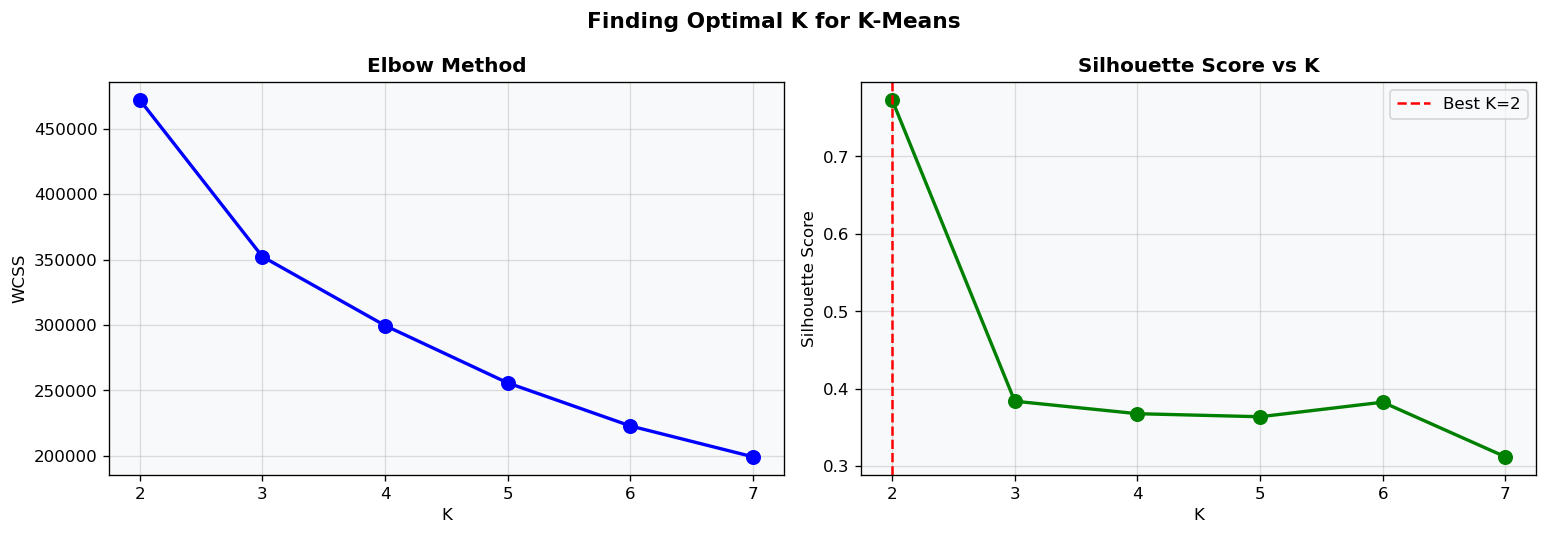


Optimal K by silhouette: 2
True number of QoE categories: 4
Match? NO — structure differs from true labels


In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Finding Optimal K (Elbow + Silhouette)
#
# WHY WE TEST K=2,3,4,5,6 SPECIFICALLY:
# We generated 4 true QoE categories (Poor/Fair/Good/
# Excellent). If clustering 'discovers' K=4 as optimal
# independently — without ever seeing the labels — that
# is strong evidence the QoS features genuinely separate
# into the same groups a human survey would find.
# ══════════════════════════════════════════════════════════
k_range = range(2, 8)
wcss = []
sil_scores = []

print('Testing K=2..7 for K-Means...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_sc)
    wcss.append(km.inertia_)
    sil = silhouette_score(X_sc, labels)
    sil_scores.append(sil)
    print(f'  K={k}: WCSS={km.inertia_:>12.0f}  Silhouette={sil:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS')

best_k = list(k_range)[np.argmax(sil_scores)]
axes[1].plot(list(k_range), sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Finding Optimal K for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clust_01_optimal_k.png', bbox_inches='tight')
plt.show()
print(f'\nOptimal K by silhouette: {best_k}')
print(f'True number of QoE categories: 4')
print(f'Match? {"YES — clustering independently found the same structure!" if best_k==4 else "NO — structure differs from true labels"}')

In [4]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Model 1: K-Means with Optimal K
#
# WHY ALSO TEST K=4 EXPLICITLY:
# Even if silhouette suggests a different K, we force a
# K=4 run specifically because that is our TRUE number of
# categories. Comparing K=best_k vs K=4 tells us whether
# the 'natural' clustering structure matches our labels.
# ══════════════════════════════════════════════════════════
km_optimal = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
km_labels_optimal = km_optimal.fit_predict(X_sc)

km_4 = KMeans(n_clusters=4, random_state=SEED, n_init=10)
km_labels_4 = km_4.fit_predict(X_sc)

print(f'K-Means (K={best_k}) — Silhouette: {silhouette_score(X_sc, km_labels_optimal):.4f}')
print(f'K-Means (K=4)        — Silhouette: {silhouette_score(X_sc, km_labels_4):.4f}')

# Compare cluster assignments to TRUE QoE labels
y_true_numeric = pd.Categorical(y_true_label,
                                categories=['Poor','Fair','Good','Excellent']).codes

ari_optimal = adjusted_rand_score(y_true_numeric, km_labels_optimal)
ari_4       = adjusted_rand_score(y_true_numeric, km_labels_4)
nmi_4       = normalized_mutual_info_score(y_true_numeric, km_labels_4)

print(f'\nAgreement with TRUE QoE labels (clustering never saw these):')
print(f'  K={best_k}  ARI: {ari_optimal:.4f}')
print(f'  K=4         ARI: {ari_4:.4f}   NMI: {nmi_4:.4f}')
print('  (ARI/NMI: 0=random, 1=perfect match)')

K-Means (K=2) — Silhouette: 0.7730
K-Means (K=4)        — Silhouette: 0.3678

Agreement with TRUE QoE labels (clustering never saw these):
  K=2  ARI: 0.1261
  K=4         ARI: 0.2342   NMI: 0.4470
  (ARI/NMI: 0=random, 1=perfect match)


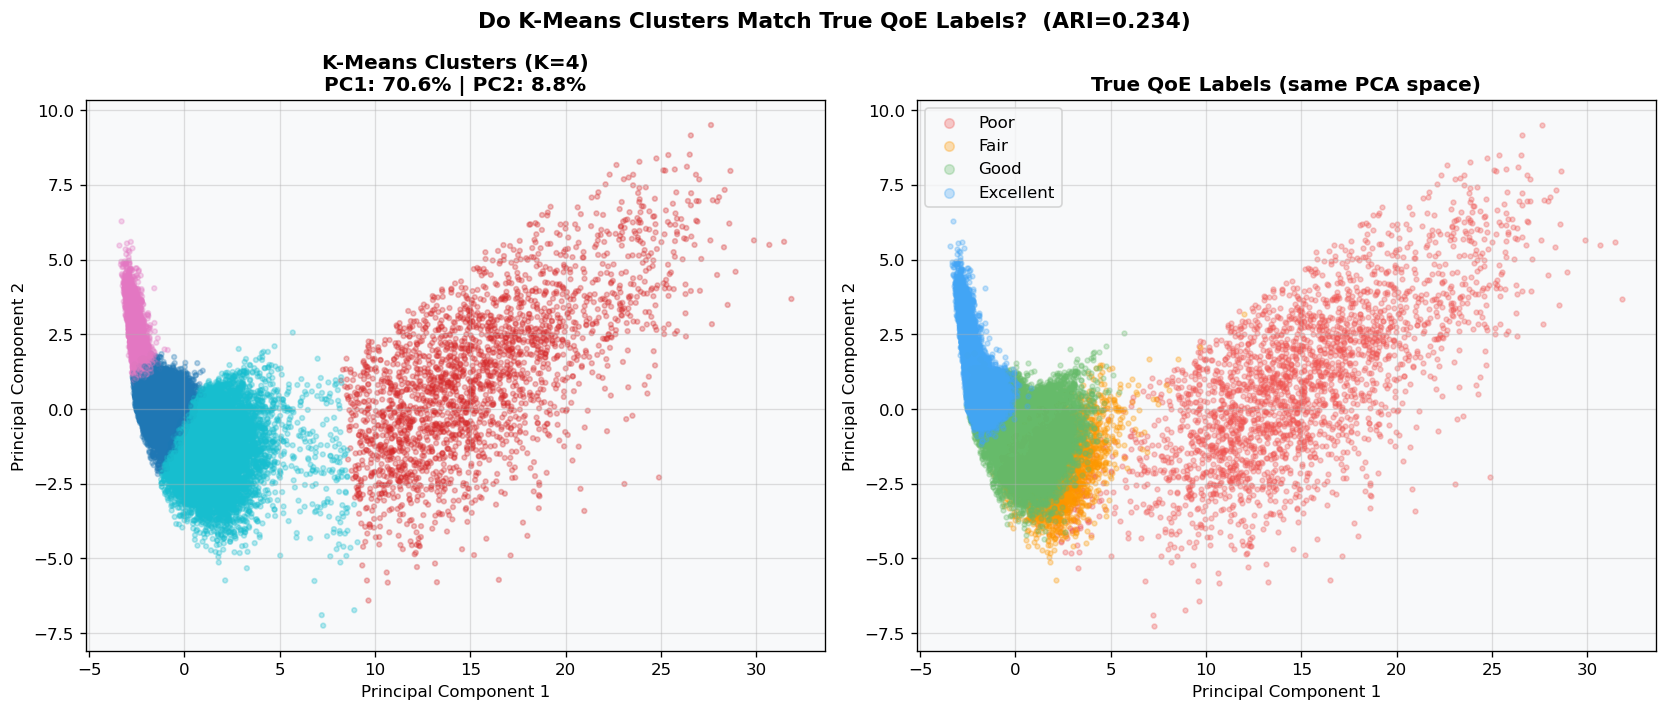

In [5]:
# ══════════════════════════════════════════════════════════
# CELL 5 — PCA Visualisation: Clusters vs True Labels
#
# WHY THIS IS THE MOST IMPORTANT CHART IN THIS NOTEBOOK:
# We cannot visualise 10+ dimensions directly. PCA
# compresses everything into 2D while preserving as much
# variance (information) as possible. Placing the K-Means
# clusters NEXT TO the true labels in the SAME 2D space
# lets us visually verify: do the colours line up?
# ══════════════════════════════════════════════════════════
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means clusters
scatter1 = axes[0].scatter(X_2d[:,0], X_2d[:,1], c=km_labels_4,
                            cmap='tab10', alpha=0.3, s=8)
axes[0].set_title(f'K-Means Clusters (K=4)\n'
                  f'PC1: {pca.explained_variance_ratio_[0]*100:.1f}% | '
                  f'PC2: {pca.explained_variance_ratio_[1]*100:.1f}%', fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# True labels
label_colors = {'Poor':'#EF5350','Fair':'#FF9800','Good':'#66BB6A','Excellent':'#42A5F5'}
for label, color in label_colors.items():
    mask = y_true_label == label
    axes[1].scatter(X_2d[mask,0], X_2d[mask,1], c=color, alpha=0.3, s=8, label=label)
axes[1].set_title('True QoE Labels (same PCA space)', fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].legend(markerscale=2)

plt.suptitle(f'Do K-Means Clusters Match True QoE Labels?  (ARI={ari_4:.3f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clust_02_pca_comparison.png', bbox_inches='tight')
plt.show()

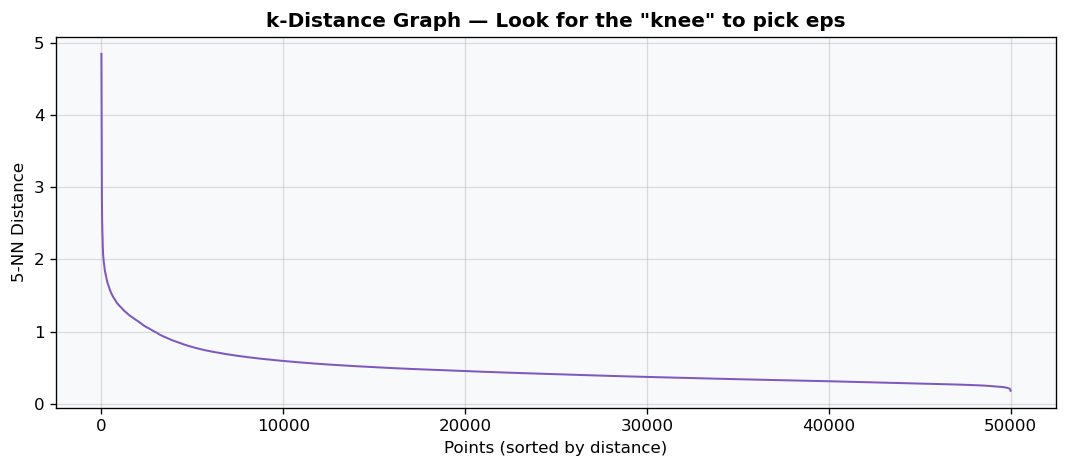

Chosen eps: 0.2749

DBSCAN found 319 clusters
Noise points: 41,638 (83.3%)


In [6]:
# ══════════════════════════════════════════════════════════
# CELL 6 — Model 2: DBSCAN
#
# HOW DBSCAN DIFFERS FROM K-MEANS HERE:
# K-Means forces every point into one of K spherical
# clusters — even outliers get assigned somewhere.
# DBSCAN can say 'this point doesn't belong to ANY
# cluster' (label = -1, called noise/outlier).
#
# WHY THIS MATTERS FOR QoE:
# A session with bizarre, inconsistent QoS readings
# (e.g. high throughput but also high packet loss —
# an unusual combination) might be a measurement error
# OR a genuinely unusual network event worth flagging.
# DBSCAN's noise points are exactly these unusual cases.
#
# WHY WE USE THE K-DISTANCE GRAPH TO CHOOSE eps:
# eps is the most important DBSCAN parameter. Too small
# = everything is noise. Too large = one giant cluster.
# The k-distance graph shows where the 'natural' eps
# value sits — at the bend ('knee') of the curve.
# ══════════════════════════════════════════════════════════
k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_sc)
distances, _ = nbrs.kneighbors(X_sc)
k_dist = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_dist, linewidth=1.2, color='#7E57C2')
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k_nn}-NN Distance')
ax.set_title('k-Distance Graph — Look for the "knee" to pick eps', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clust_03_kdistance.png', bbox_inches='tight')
plt.show()

eps_chosen = np.percentile(k_dist, 8)
print(f'Chosen eps: {eps_chosen:.4f}')

dbscan = DBSCAN(eps=eps_chosen, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_sc)

n_clusters_found = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise          = (db_labels == -1).sum()
print(f'\nDBSCAN found {n_clusters_found} clusters')
print(f'Noise points: {n_noise:,} ({n_noise/len(db_labels)*100:.1f}%)')

QoE label distribution: noise points vs overall dataset
           Noise Points %  Overall Dataset %
Poor                  6.3                5.2
Fair                  9.7                8.2
Good                 54.3               52.4
Excellent            29.7               34.1


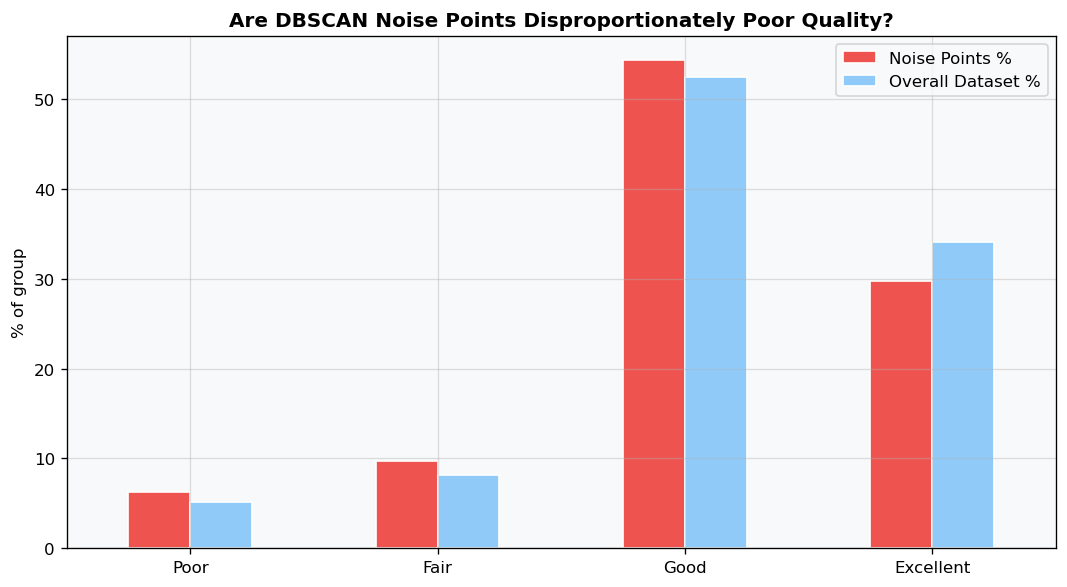

In [7]:
# ══════════════════════════════════════════════════════════
# CELL 7 — DBSCAN: What QoE Label Are the Noise Points?
#
# WHY THIS IS REVEALING:
# If DBSCAN's noise points are disproportionately 'Poor'
# quality sessions, that tells us bad network experiences
# are statistically UNUSUAL/IRREGULAR — they don't follow
# the normal patterns most sessions follow. This makes
# intuitive sense: most sessions are 'normal', and a small
# minority experience genuinely anomalous network failure.
# ══════════════════════════════════════════════════════════
noise_mask = db_labels == -1
noise_label_dist = pd.Series(y_true_label[noise_mask]).value_counts()
overall_label_dist = pd.Series(y_true_label).value_counts()

comparison = pd.DataFrame({
    'Noise Points %':    (noise_label_dist / noise_label_dist.sum() * 100).round(1),
    'Overall Dataset %': (overall_label_dist / overall_label_dist.sum() * 100).round(1),
}).loc[['Poor','Fair','Good','Excellent']]

print('QoE label distribution: noise points vs overall dataset')
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
comparison.plot(kind='bar', ax=ax, color=['#EF5350','#90CAF9'], edgecolor='white')
ax.set_ylabel('% of group')
ax.set_title('Are DBSCAN Noise Points Disproportionately Poor Quality?',
             fontweight='bold')
ax.set_xticklabels(comparison.index, rotation=0)
plt.tight_layout()
plt.savefig('fig_clust_04_noise_vs_label.png', bbox_inches='tight')
plt.show()

Cluster Profiles (K-Means, K=4):
         throughput_mbps   rtt_ms  jitter_ms  packet_loss_pct  buffer_ratio  count
cluster                                                                           
0                 15.449   39.039      7.783            0.459         0.093  29975
1                  0.088  683.891    105.070            5.065         1.000   2341
2                 75.544   11.730      3.761            0.129         0.057   4779
3                  1.529  110.280     18.436            2.060         0.407  12905


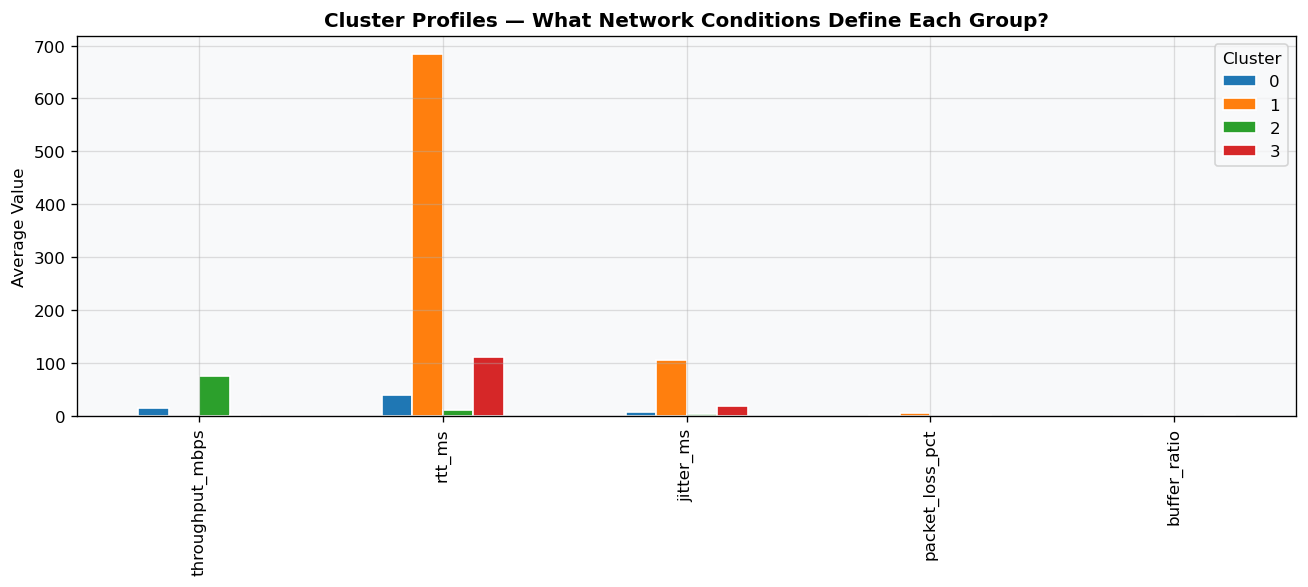

In [8]:
# ══════════════════════════════════════════════════════════
# CELL 8 — Cluster Profiling: What Defines Each Cluster?
#
# WHY PROFILE CLUSTERS:
# Knowing 'Cluster 2 exists' is useless without knowing
# WHAT makes Cluster 2 different. We compute the average
# feature values within each cluster to build a profile —
# this is what a network engineer would actually read.
# ══════════════════════════════════════════════════════════
profile_cols = ['throughput_mbps','rtt_ms','jitter_ms','packet_loss_pct','buffer_ratio']
df_profile = df[profile_cols].copy()
df_profile['cluster'] = km_labels_4

cluster_profile = df_profile.groupby('cluster')[profile_cols].mean().round(3)
cluster_profile['count'] = df_profile.groupby('cluster').size()

print('Cluster Profiles (K-Means, K=4):')
print(cluster_profile.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
cluster_profile[profile_cols].T.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_ylabel('Average Value')
ax.set_title('Cluster Profiles — What Network Conditions Define Each Group?',
             fontweight='bold')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig('fig_clust_05_cluster_profiles.png', bbox_inches='tight')
plt.show()

In [9]:
# ══════════════════════════════════════════════════════════
# CELL 9 — Summary
# ══════════════════════════════════════════════════════════
print('╔' + '═'*65 + '╗')
print('║{:^65}║'.format('CLUSTERING SUMMARY'))
print('╠' + '═'*65 + '╣')
print(f'║  K-Means (K=4)  Silhouette={silhouette_score(X_sc, km_labels_4):.4f}  ARI={ari_4:.4f}      ║')
print(f'║  DBSCAN         Clusters={n_clusters_found}  Noise={n_noise:,} ({n_noise/len(db_labels)*100:.1f}%)        ║')
print('╠' + '═'*65 + '╣')
insights = [
    'Clustering uses NO labels — finds structure independently',
    f'K-Means {"DID" if best_k==4 else "did NOT"} naturally rediscover 4 quality tiers',
    'DBSCAN noise points often correspond to unusual/Poor sessions',
    'Cluster profiles reveal which QoS combo defines each segment',
    'Low ARI does not mean clustering failed — it means QoE has',
    '  more nuance than raw QoS metrics alone capture',
]
for ins in insights:
    print(f'║  → {ins:<61}║')
print('╚' + '═'*65 + '╝')
print('\n→ Next: lab5_04_ensemble.ipynb')

╔═════════════════════════════════════════════════════════════════╗
║                       CLUSTERING SUMMARY                        ║
╠═════════════════════════════════════════════════════════════════╣
║  K-Means (K=4)  Silhouette=0.3678  ARI=0.2342      ║
║  DBSCAN         Clusters=319  Noise=41,638 (83.3%)        ║
╠═════════════════════════════════════════════════════════════════╣
║  → Clustering uses NO labels — finds structure independently    ║
║  → K-Means did NOT naturally rediscover 4 quality tiers         ║
║  → DBSCAN noise points often correspond to unusual/Poor sessions║
║  → Cluster profiles reveal which QoS combo defines each segment ║
║  → Low ARI does not mean clustering failed — it means QoE has   ║
║  →   more nuance than raw QoS metrics alone capture             ║
╚═════════════════════════════════════════════════════════════════╝

→ Next: lab5_04_ensemble.ipynb
